# Task 2 - Data Visualization
## Superstore Dataset Analysis

This notebook focuses on visualizing data patterns, trends, and business insights using charts and graphs.

# 1) Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

# 2) Load Dataset

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [14]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")



#3) Dataset Preview

In [15]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# 4)  Dataset Overview

In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


### Missing Values Check

In [19]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


No missing values were found in the dataset.

# 5) Visualization 1: Sales by Category

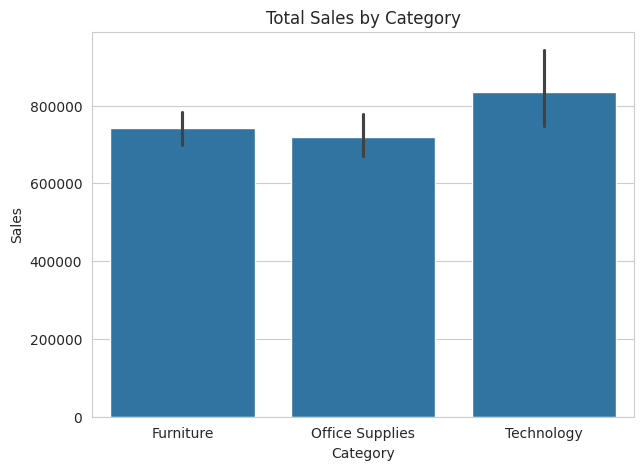

In [10]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x='Category', y='Sales', estimator=sum)

plt.title("Total Sales by Category")
plt.show()

### Insight
Technology has the highest total sales compared to other categories.

# 6) Visualization 2: Profit by Category

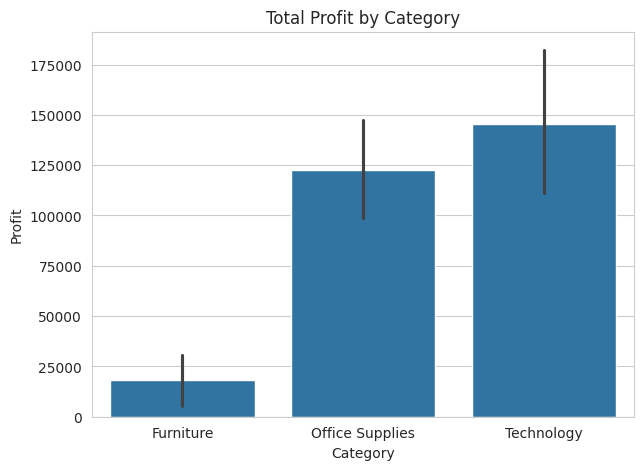

In [9]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x='Category', y='Profit', estimator=sum)

plt.title("Total Profit by Category")
plt.show()

### Insight
Technology generates the highest profit, while Furniture may have lower profitability.

# 7) Visualization 3: Sales by Region

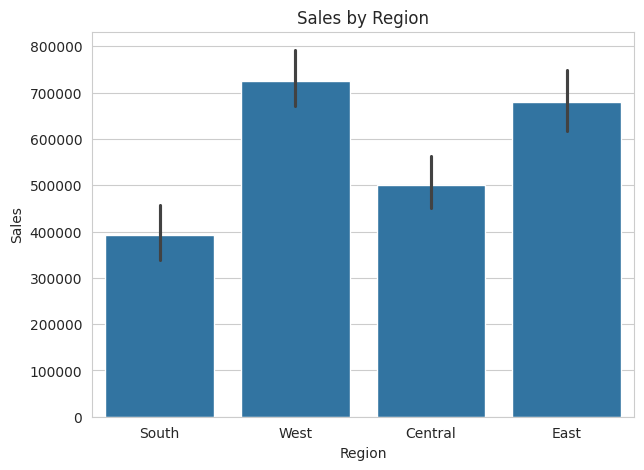

In [11]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x='Region', y='Sales', estimator=sum)

plt.title("Sales by Region")
plt.show()

### Insight
West region shows the strongest sales performance.

# 8) Visualization 4: Profit vs Discount

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='Discount', y='Profit')

plt.title("Discount vs Profit")
plt.show()

### Insight
Higher discounts often lead to lower profit, showing a negative relationship.

# 9) Visualization 5: Sales Trend (Over Time)

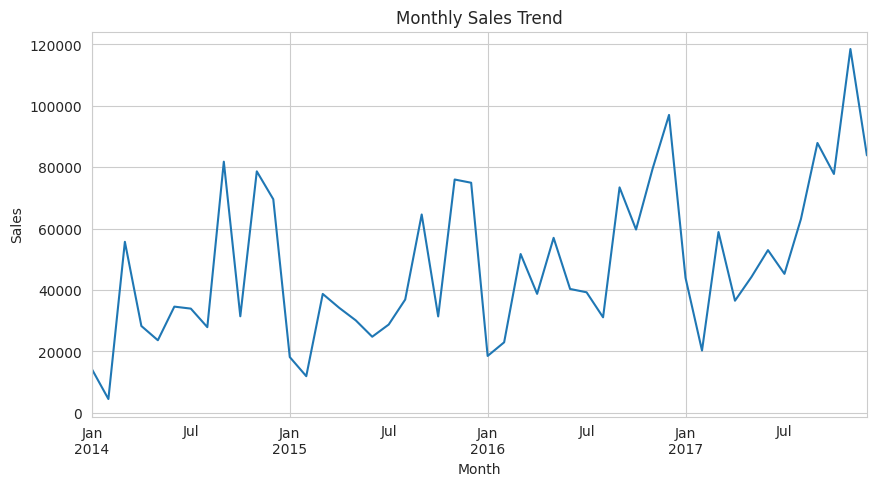

In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum().sort_index()

monthly_sales.plot(kind='line', figsize=(10,5))

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

# 10) Visualization 6: Top Sub-Categories

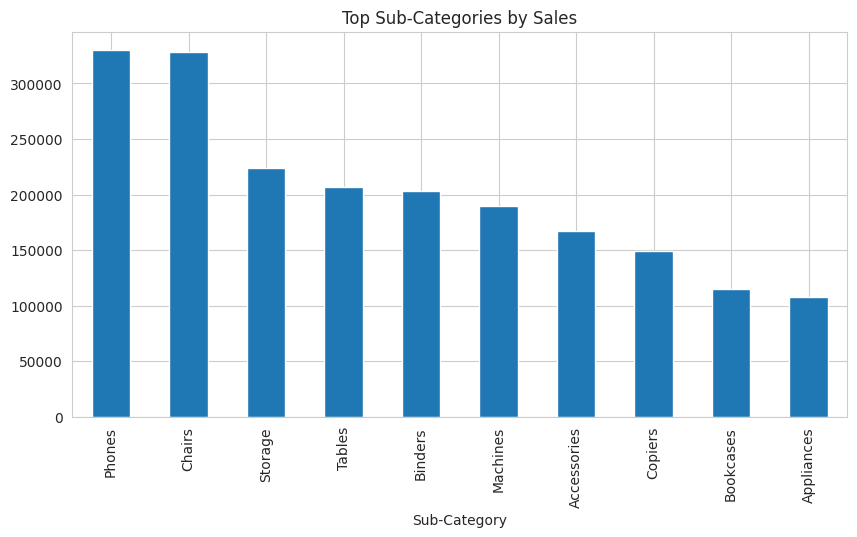

In [13]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

top_sub.head(10).plot(kind='bar', figsize=(10,5))

plt.title("Top Sub-Categories by Sales")
plt.show()

## Final Insights

- Technology is the leading category in both sales and profit, indicating strong market demand.
- The West region shows the highest performance and should be a focus for expansion.
- Discounts negatively impact profit, suggesting careful discount strategy is needed.
- Sales show seasonal fluctuations over time.
- Certain sub-categories dominate overall revenue.